<a href="https://colab.research.google.com/github/sambee5/data-science-coursework/blob/main/Unit4/SamarthBUnit4ExerciesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
import pymc as pm
import preliz as pz

# Unit 4 Exercises: Tinkering Hierarchical Models

These exercises are designed to force you to look at the nuances of the models we looked at in class, while exploring some "what ifs". There's also some mild data wrangling for you to enjoy at in task6.



**Task1**:

Redo the chemical shift hierarchical model, execpt with all Student T and Half Student T likelihood and priors.

Then, compare group posteriors of the normal chem shift model with your new Student T model using a ridge plot.

In [7]:
url_cs = 'https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/chemical_shifts_theo_exp.csv'
cs_data = pd.read_csv(url_cs)
diff_TminusE = cs_data.theo - cs_data.exp
cs_data.insert(loc=4,column='diff_TminusE',value=diff_TminusE)
cs_data

,ID,aa,theo,exp,diff_TminusE,cat
0,1BM8,ILE,61.18,58.27,2.91,Non-Polar
1,1BM8,TYR,56.95,56.18,0.77,Polar
2,1BM8,SER,56.35,56.84,-0.49,Polar
3,1BM8,ALA,51.96,51.01,0.95,Special
4,1BM8,ARG,56.54,54.64,1.90,Charged
...,...,...,...,...,...,...
1771,1KS9,LYS,55.79,57.51,-1.72,Charged
1772,1KS9,ARG,58.91,59.02,-0.11,Charged
1773,1KS9,LYS,59.49,58.92,0.57,Charged
1774,1KS9,GLU,59.48,58.36,1.12,Charged


In [8]:
#identifies all the different amino acids in our data set
#and stores that information, plus original info, in the variable aa_encode
aa_encode = pd.Categorical(cs_data['aa'])
aa_encode


['ILE', 'TYR', 'SER', 'ALA', 'ARG', ..., 'LYS', 'ARG', 'LYS', 'GLU', 'SER']
Length: 1776
Categories (19, object): ['ALA', 'ARG', 'ASN', 'ASP', ..., 'THR', 'TRP', 'TYR', 'VAL']

In [9]:
aa_encode = pd.Categorical(cs_data['aa'])
aa_idx = aa_encode.codes
aa_coords = {"aa": aa_encode.categories}

The StudentT hierarchical model.

In [ ]:
with pm.Model(coords=aa_coords) as cs_h_model_ST:
    # hyperpriors. Notice how there's no dims argument.
    #this means that the hyperprior is shared across all amino acids
    μ_mu = pm.StudentT('μ_mu', mu = 0, sigma = 10, nu=30)
    μ_sd = pm.HalfStudentT('μ_sd', sigma = 10, nu=30)
    μ_nu = pm.HalfStudentT('μ_nu', sigma = 10, nu=30)

    # priors. There is a different prior for each amino acid,
    #but now the μ priors 'talk' to one another through μ_mu and μ_sd
    μ = pm.StudentT('μ',
                  nu=μ_nu, #hyperprior 1
                  mu = μ_mu, #hyperprior 2
                  sigma = μ_sd, #hyperprior 3
                  dims = "aa")

    v=pm.HalfStudentT('v', sigma = 10, nu=30, dims="aa")

    σ = pm.HalfStudentT('σ',
                      nu = 30,
                      sigma = 10,
                      dims = "aa")

    #likelihood; same as before
    y = pm.StudentT('y',
                  mu = μ[aa_idx], #I include the prior in my likelihood
                  sigma = σ[aa_idx], #I include the prior in my likelihood
                  nu = v[aa_idx],
                  observed = cs_data.diff_TminusE)

    #cs for chemshift, h for heirarchical
    idata_cs_h_ST = pm.sample()

The normal hierarchical model (took from notes)

In [ ]:

with pm.Model(coords=aa_coords) as cs_h_model_N:
    # hyperpriors. Notice how there's no dims argument.
    #this means that the hyperprior is shared across all amino acids
    μ_mu = pm.Normal('μ_mu', mu = 0, sigma = 10)
    μ_sd = pm.HalfNormal('μ_sd', sigma = 10)

    # priors. There is a different prior for each amino acid,
    #but now the μ priors 'talk' to one another through μ_mu and μ_sd
    μ = pm.Normal('μ',
                  mu = μ_mu, # I include the hyperprior in my prior
                  sigma = μ_sd, # I include the hyperprior in my prior
                  dims = "aa")

    σ = pm.HalfNormal('σ', sigma = 10,
                      dims = "aa")

    #likelihood; same as before
    y = pm.Normal('y',
                  mu = μ[aa_idx], #I include the prior in my likelihood
                  sigma = σ[aa_idx], #I include the prior in my likelihood
                  observed = cs_data.diff_TminusE)

    #cs for chemshift, h for heirarchical
    idata_cs_h_N = pm.sample()

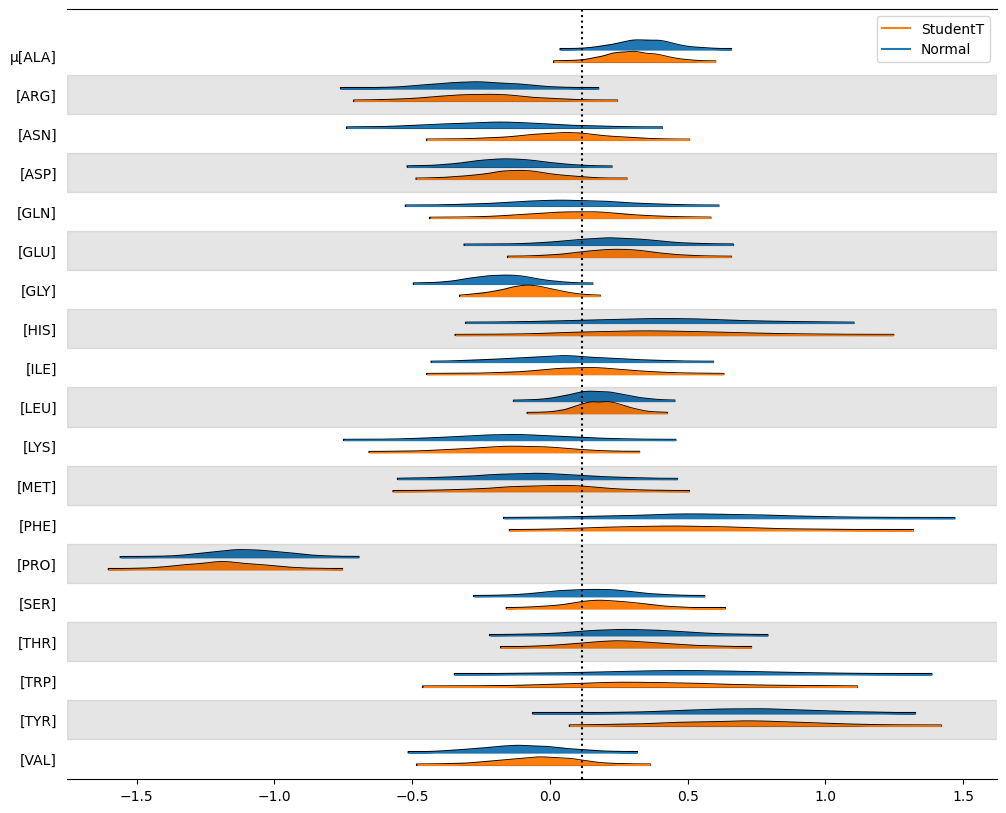

In [12]:
#plots a 99.7% hdi for the posteriors of both models on the same plot
axes = az.plot_forest([idata_cs_h_N, idata_cs_h_ST], kind="ridgeplot",
                      model_names=['Normal', 'StudentT'],
                      var_names='μ', combined=True, figsize=(12, 10),hdi_prob=0.997)

#plots overall mean of the hierarchical model; do not confuse with 0
y_lims = axes[0].get_ylim()
axes[0].vlines(idata_cs_h_ST.posterior['μ_mu'].mean(), *y_lims, color="k", ls=":");

**Task2**:

Run a posterior predictive check for both models. Which seems to fit the data better?

Normal hierarchical model PPC

In [ ]:
pm.sample_posterior_predictive(idata_cs_h_N, model=cs_h_model_N, extend_inferencedata=True)

<Axes: xlabel='y'>

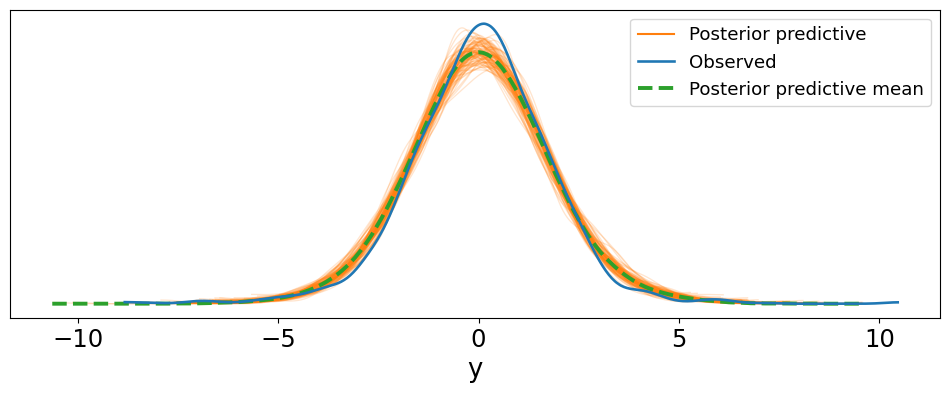

In [14]:
az.plot_ppc(idata_cs_h_N, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C2"])

I'm not going to call this terrible or anything, this model is better than what I created for the Unit 3 project :)





Student T hierchical model PPC

In [ ]:
pm.sample_posterior_predictive(idata_cs_h_ST, model=cs_h_model_ST, extend_inferencedata=True)

(-15.0, 15.0)

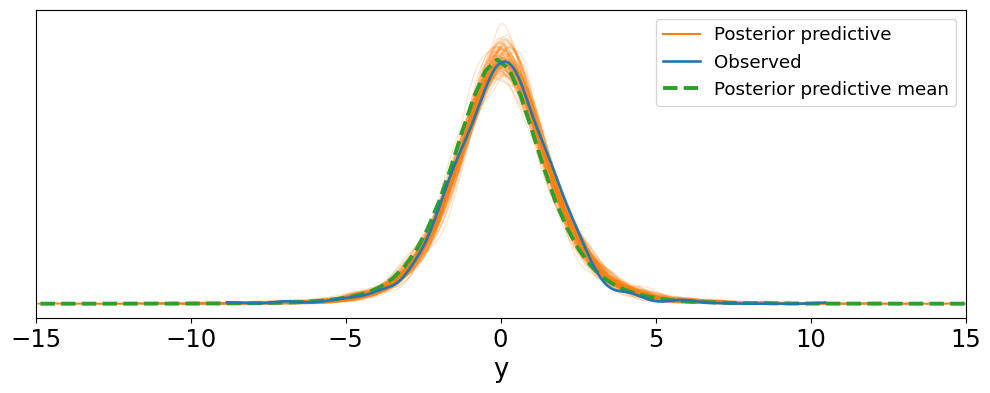

In [16]:
ax=az.plot_ppc(idata_cs_h_ST, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C2"])
# ax.set_xlim(-5, 5)
ax.set_xlim(-15,15)

The StudentT heirchical model fits the observed data better than Normal model. We can see that for the graph above (StudentT), the peak of the posterior predictive mean is a lot closer to the peak of the observed data, which is a good indication of model accuracy. However, we can see this less in the Normal model, as the model tends to undershoot the observed data. In terms of skew, both models aren't spot on, but accurate enough to where it doesn't create a substantial issue.





**Task3**:

Redo the soccer model, but this time, assume the groups are independent. This will be a non-hierarchical model.

In [17]:
url_sccr = 'https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/football_players.csv'
sccr_data = pd.read_csv(url_sccr,dtype={'position':'category'})
sccr_data

,name,position,goals,shots
0,Aaron Connolly,FW,5,59
1,Aaron Cresswell,DF,4,69
2,Aaron Hunt,MF,3,30
3,Aaron Lennon,MF,1,5
4,Aaron Leya Iseka,FW,10,76
...,...,...,...,...
2677,Óscar Mingueza,DF,2,12
2678,Óscar Plano,MF,12,124
2679,Óscar Rodríguez,MF,13,133
2680,Óscar Trejo,MF,1,20


In [18]:

#this is an array of the soccer positions,
#except they are given an int (number) label instead of a string (of letters)
pos_idx = sccr_data.position.cat.codes.values

#an array of the four strings that represent position
pos_codes = sccr_data.position.cat.categories

#puts coords in a dict, so pymc can read them
sccr_coords = {"pos": pos_codes}

In [19]:
sccr_coords

{'pos': Index(['DF', 'FW', 'GK', 'MF'], dtype='object')}

Hierarchical models don't have hyper parameters.

In [ ]:
with pm.Model(coords = sccr_coords) as sccr_model:
    # Parameters for positions
    μ_p = pm.Beta('μ_p', alpha=2, beta=20, dims = "pos")

    ν_p = pm.Gamma('ν_p', mu = 55, sigma = 45, dims="pos")

    # Parameter for players
    θ = pm.Beta('θ', mu = μ_p[pos_idx], nu = ν_p[pos_idx])

    #This tells our model how many shots and goals each player has
    _ = pm.Binomial('gs',
                    n = sccr_data.shots.values, #shots for each player
                    p = θ, #guess of goals per shot
                    observed = sccr_data.goals.values) #goals per player

    #target_accept has a default of 0.8. Increasing it makes us less likely to
    #have divergences
    idata_sccr = pm.sample(target_accept = 0.95)

**Task4**:

Run plot trace and rhat on your inference data object for the non-hierarchical soccer model. How does this compare to the hierarchical model?

array([[<Axes: title={'center': 'θ'}>, <Axes: title={'center': 'θ'}>],
       [<Axes: title={'center': 'μ_p'}>, <Axes: title={'center': 'μ_p'}>],
       [<Axes: title={'center': 'ν_p'}>, <Axes: title={'center': 'ν_p'}>]],
      dtype=object)

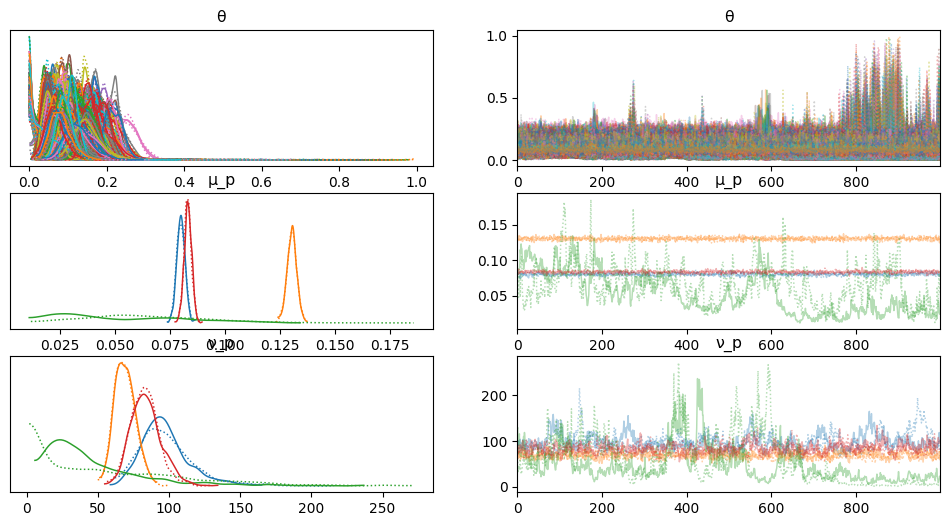

In [21]:
az.plot_trace(idata_sccr)

In [22]:
az.rhat(idata_sccr)

<xarray.Dataset> Size: 43kB
Dimensions:  (θ_dim_0: 2682, pos: 4)
Coordinates:
  * θ_dim_0  (θ_dim_0) int64 21kB 0 1 2 3 4 5 ... 2676 2677 2678 2679 2680 2681
  * pos      (pos) <U2 32B 'DF' 'FW' 'GK' 'MF'
Data variables:
    θ        (θ_dim_0) float64 21kB 0.9995 1.002 1.0 1.001 ... 1.002 1.0 1.007
    μ_p      (pos) float64 32B 1.002 0.9993 1.228 1.002
    ν_p      (pos) float64 32B 1.013 1.001 1.174 1.015

The hierchical model and the non hierchical both have similar $\theta$ and $\mu\_p$ plots. The values of theta in the AK are very close to 1, with the highest being 1.001. In my model here, the highest value is 1.005. My plot for $\theta$ has more variance than the non hierarchical model. This likely explains why there is a larger max value for what this model's theta was compared to the other model.
The plots for $\mu\_p$ are also very similar for both models. The only significant difference between the two are the peaks of each graph. This is probably because the simulation doesn't produce the same values every time. They are close enough to where we can be fairly certain that they are similar.
v_p is a LOT different thourh. For example, the scale itself is very different. The hierarchical model in the notes are significantly smaller (fractions), while the scale for my model here is in the hundreds. Hopefully that is intended and I didn't do anything wrong...





**Task5**:

Plot the posterior of the means for each soccer position in the non-hierarchical model.

How do these posteriors compare to the hierarchical model we did in class?

array([<Axes: >], dtype=object)

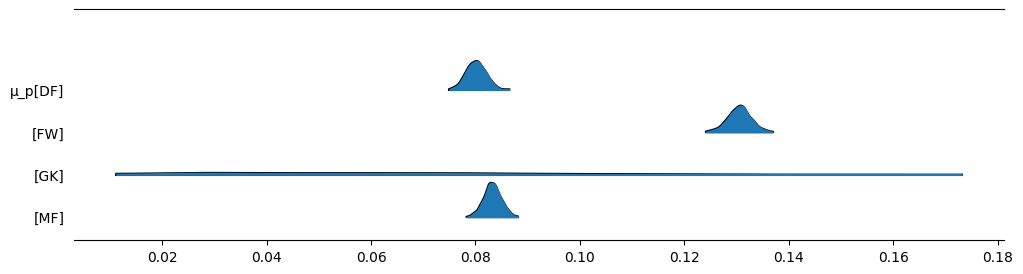

In [23]:
az.plot_forest(idata_sccr, var_names=['μ_p'], combined=True, figsize=(12, 3), kind = 'ridgeplot', hdi_prob=0.998)

The posteriors are pretty similar to the one we did in class. The means of each posterior is very similar to that of the hierchical model. However, a noticable difference between both models is the GK posterior. In the hierchical model displayed in the notes, the range of all the values are less than that of the non hierchical model. I think this is a statement of accuracy in how hierchical models treat unknown data. Non hierchical models are less sure about what the truth/mean actually is, so the range is larger.


**Task6**:

Redo the soccer model as a hierarchical model, but remove all the goalkeepers (GK) from the data. In other words, run a hierarchical model on only the defenders, midfielders, and forwards.

In [24]:
#create a new dataframe with the same soccer data as before
url_sccr = 'https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/football_players.csv'
sccr_data2 = pd.read_csv(url_sccr)
sccr_data2 = sccr_data2.query('position != "GK"')

sccr_data2['position'] = sccr_data2['position'].astype("category")
sccr_data2

,name,position,goals,shots
0,Aaron Connolly,FW,5,59
1,Aaron Cresswell,DF,4,69
2,Aaron Hunt,MF,3,30
3,Aaron Lennon,MF,1,5
4,Aaron Leya Iseka,FW,10,76
...,...,...,...,...
2677,Óscar Mingueza,DF,2,12
2678,Óscar Plano,MF,12,124
2679,Óscar Rodríguez,MF,13,133
2680,Óscar Trejo,MF,1,20


In [25]:
#now all the position IDs are without the goalkeeper position
pos_idx2 = sccr_data2.position.cat.codes.values
pos_codes2 = sccr_data2.position.cat.categories
sccr_coords2 = {"pos": pos_codes2}

pos_codes2

Index(['DF', 'FW', 'MF'], dtype='object')

In [ ]:
with pm.Model(coords = sccr_coords2) as sccr_model:
    # Hyper parameters
    #
    μ = pm.Beta('μ', alpha = 2, beta = 20)
    ν = pm.Gamma('ν', mu = 55, sigma = 45)


    # Parameters for positions
    μ_p = pm.Beta('μ_p', mu = μ, nu = ν, dims = "pos")

    ν_p = pm.Gamma('ν_p', mu = 55, sigma = 45, dims="pos")

    # Parameter for players
    θ = pm.Beta('θ', mu = μ_p[pos_idx2], nu = ν_p[pos_idx2])

    #This tells our model how many shots and goals each player has
    _ = pm.Binomial('gs',
                    n = sccr_data2.shots.values, #shots for each player
                    p = θ, #guess of goals per shot
                    observed = sccr_data2.goals.values) #goals per player

    #target_accept has a default of 0.8. Increasing it makes us less likely to
    #have divergences
    idata_sccr_noGK = pm.sample(target_accept = 0.95)

**Task7**:

Compare the plot trace and rhat results for the hierarchical model with GKs and without GKs. Then answer the following questions:
- Which model was easier for pymc to process?
- What do we lose by dropping Gks from the data set? What do we gain?

Below are the rhat and plot trace results without GK

array([[<Axes: title={'center': 'θ'}>, <Axes: title={'center': 'θ'}>],
       [<Axes: title={'center': 'μ'}>, <Axes: title={'center': 'μ'}>],
       [<Axes: title={'center': 'μ_p'}>, <Axes: title={'center': 'μ_p'}>],
       [<Axes: title={'center': 'ν'}>, <Axes: title={'center': 'ν'}>],
       [<Axes: title={'center': 'ν_p'}>, <Axes: title={'center': 'ν_p'}>]],
      dtype=object)

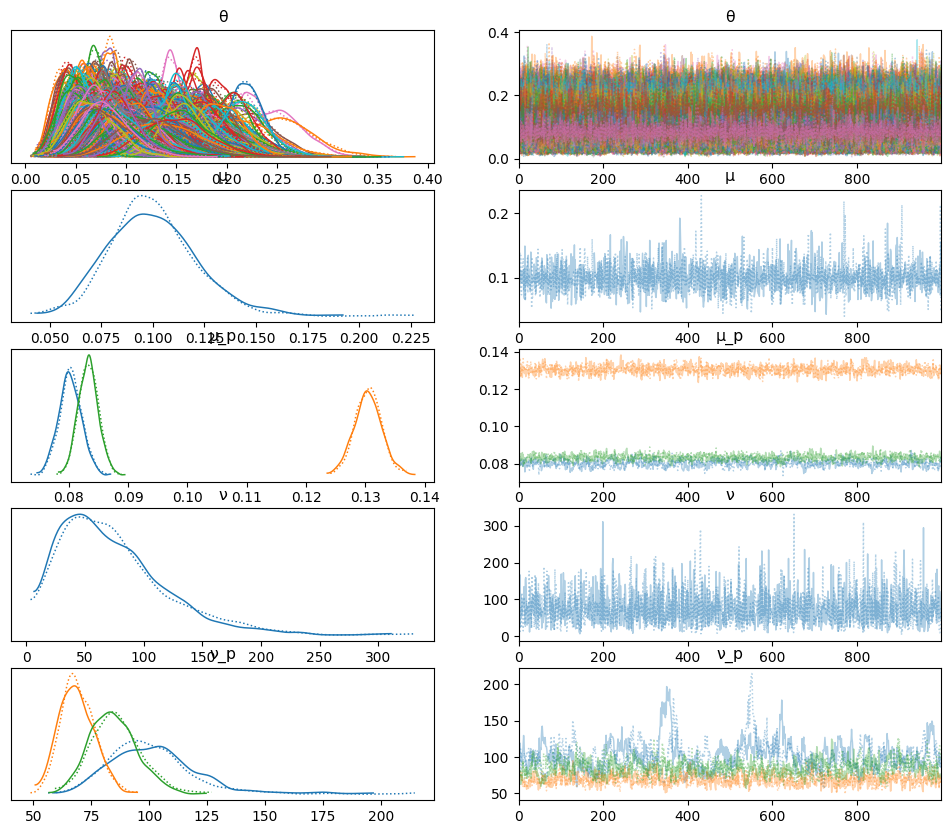

In [27]:
az.plot_trace(idata_sccr_noGK)

In [28]:
az.rhat(idata_sccr_noGK)

<xarray.Dataset> Size: 40kB
Dimensions:  (θ_dim_0: 2517, pos: 3)
Coordinates:
  * θ_dim_0  (θ_dim_0) int64 20kB 0 1 2 3 4 5 ... 2511 2512 2513 2514 2515 2516
  * pos      (pos) <U2 24B 'DF' 'FW' 'MF'
Data variables:
    θ        (θ_dim_0) float64 20kB 0.9998 1.0 1.001 1.008 ... 1.0 0.9992 0.9995
    μ        float64 8B 1.003
    μ_p      (pos) float64 24B 1.002 1.0 1.001
    ν        float64 8B 0.9993
    ν_p      (pos) float64 24B 1.007 1.002 1.005

I guess the model without the GK was easier for pymc to process. THere are a number of reasons for why this might be the case. There is clearly less data once we reduce the amount of goalkeepers we're factoring in. (less data = faster processing = better result?)

Also we can see that the posterior of all the goalkeepers data is super weird. I doubt pymc enjoys processing this weird data, so removing it means less things to worry about and therefore faster processing. The model that pymc spent to process that data was rougly less than if did when the goalkeepers were left in (when I was doing the notes a couple days ago)
You lose information about GK (obviously) if you don't include them in that dataset.
